In [1]:
# This file was sent by Liu Mingxin, who update the 'BTMS eval vs power generattion.ipynb' to account for liquid cooling. 
# The original file saved with an FID: HP02E030107A2  code_liquid_cooling_BLC_15cells_1200s_newFAC_modified_no_0D_with_natconv_Liu_20260518.ipynb

# read the newest 18650FAC heat-generation profile from the same directory as this notebook

import os
import sys
import numpy as np
import pandas as pd

# User-provided heat-generation file. Keep the normal local filename first.
# In this chat environment the newest uploaded copy is 18650FAC(2).xlsx, so it is
# checked before the older 18650FAC(1).xlsx fallback.
# CANDIDATE_DATA_FILES = ["18650FAC.xlsx", "18650FAC(2).xlsx", "18650FAC(1).xlsx"]


# update the file name for the current folder



# def find_data_file(candidate_names):
#     """Find the heat-generation workbook in the current notebook directory."""
#     search_dirs = [os.getcwd()]
#     for directory in search_dirs:
#         for name in candidate_names:
#             path = os.path.join(directory, name)
#             if os.path.exists(path):
#                 return path
#     raise FileNotFoundError(
#         "Could not find 18650FAC.xlsx in the notebook directory. "
#         "Please place the newest 18650FAC workbook next to this notebook."
#     )


def normalize_column_name(name):
    """Normalize column names for robust matching."""
    return str(name).strip().lower().replace(" ", "")


def find_column(dataframe, candidates):
    """Find a column by case/space-insensitive matching."""
    normalized = {normalize_column_name(col): col for col in dataframe.columns}
    for candidate in candidates:
        key = normalize_column_name(candidate)
        if key in normalized:
            return normalized[key]
    raise KeyError(f"None of the expected columns were found: {candidates}. Existing columns: {list(dataframe.columns)}")


def numeric_series(dataframe, candidates):
    """Return a numeric Series from the first matching candidate column."""
    col = find_column(dataframe, candidates)
    series = pd.to_numeric(dataframe[col], errors="coerce").dropna()
    return col, series


def first_float_or_none(dataframe, candidates):
    """Read the first numeric value from a candidate column, if it exists."""
    try:
        _, values = numeric_series(dataframe, candidates)
    except KeyError:
        return None
    if values.empty:
        return None
    return float(values.iloc[0])



In [2]:


file_name = os.path.join(os.getcwd(), "data", "HP02E030111A1  result_Q_liquid cooling_18650FAC.xlsx") 
df = pd.read_excel(file_name, sheet_name="Sheet1")

# Geometry values in the new 18650FAC file.
H_bat_from_file = first_float_or_none(df, ["H(高度)", "H", "height", "Height"])
D_bat_from_file = first_float_or_none(df, ["D(直径)", "D", "diameter", "Diameter"])
H_bat_for_q = H_bat_from_file if H_bat_from_file is not None else 65e-3
D_bat_for_q = D_bat_from_file if D_bat_from_file is not None else 18e-3
V_bat_for_q = np.pi * D_bat_for_q ** 2 / 4.0 * H_bat_for_q

# The newest 18650FAC file has a complete 1200-row Qbat(W) column, so use it
# directly as the single-cell heat-generation power. Do not use Qpack(W), because
# this BLC reproduction uses 15 cells and the total module heat is assembled from
# 15 single-cell values inside the model.
try:
    power_col, power_series = numeric_series(df, ["Qbat(W)", "Qbat", "qbat(W)"])
    power_generation_data = power_series.to_numpy(dtype=float)
    power_source_note = f"{power_col} directly, single-cell heat generation"
except KeyError:
    # Fallback: if a future workbook omits Qbat(W), compute single-cell power from qbat(W/m^3).
    qvol_col, qvol_series = numeric_series(df, ["qbat(W/m^3)", "qbat(W/m3)", "qbat", "qgen(W/m^3)", "qgen"])
    power_generation_data = qvol_series.to_numpy(dtype=float) * V_bat_for_q
    power_col = qvol_col
    power_source_note = f"{qvol_col} multiplied by computed cell volume {V_bat_for_q:.8e} m^3"

# Each row is one 1-second heat-generation interval. 1200 rows => states from 0 to 1200 s.
dt = 1.0
heat_generation_steps = len(power_generation_data)
simulation_duration_s = heat_generation_steps * dt

if heat_generation_steps != 1200:
    print(f"WARNING: heat-generation data contains {heat_generation_steps} rows, not 1200 rows.")

print(f"Loaded heat-generation data from: {file_name}")
print(f"Power source: {power_source_note}")
print(f"Heat-generation intervals: {heat_generation_steps}; simulation end time: {simulation_duration_s:.0f} s")
print(f"Power range: min={np.min(power_generation_data):.6g} W, max={np.max(power_generation_data):.6g} W, mean={np.mean(power_generation_data):.6g} W per cell")
print(f"Battery geometry from file: H={H_bat_from_file} m, D={D_bat_from_file} m, V={V_bat_for_q:.8e} m^3")


Loaded heat-generation data from: d:\Workspace\eBATS\data\HP02E030111A1  result_Q_liquid cooling_18650FAC.xlsx
Power source: Qbat(W) directly, single-cell heat generation
Heat-generation intervals: 1200; simulation end time: 1200 s
Power range: min=0.927676 W, max=2.62219 W, mean=1.27182 W per cell
Battery geometry from file: H=0.065 m, D=0.018 m, V=1.65404853e-05 m^3


In [3]:
# Battery parameters for NCR18650PF cylindrical cells used in the Zhang et al. 2024 BLC case.
# The heat-generation file has 1200 rows. With dt = 1 s, the state arrays must have 1201 rows:
# t = 0, 1, 2, ..., 1200 s.

T_bat_init = 25.0  # initial battery temperature in Celsius
cp_bat = 877.24    # J/(kg·K), from the paper table for the 18650 cell
m_bat = 47e-3      # kg, mass of one 18650 cell
D_bat = D_bat_from_file if D_bat_from_file is not None else 18e-3  # m
H_bat = H_bat_from_file if H_bat_from_file is not None else 65e-3  # m
N_cells = 15       # BLC case: 15 cells, 5S3P module

A_battery = np.pi * D_bat * H_bat  # lateral surface area of one cylindrical cell, m^2
num_time_steps = heat_generation_steps + 1

# Adiabatic single-cell temperature rise from the new heat-generation profile.
T_bat = np.zeros(num_time_steps)
T_bat[0] = T_bat_init

for i in range(1, num_time_steps):
    # power_generation_data[i-1] is the heat generated during interval (i-1, i].
    dT = (power_generation_data[i - 1] * dt) / (m_bat * cp_bat)
    T_bat[i] = T_bat[i - 1] + dT

print(
    f"Battery setup: N_cells={N_cells}, m_bat={m_bat:.6g} kg, cp_bat={cp_bat:.6g} J/(kg·K), "
    f"D_bat={D_bat:.6g} m, H_bat={H_bat:.6g} m"
)
print(f"Simulation time grid: {num_time_steps} state points, t = 0 to {(num_time_steps-1)*dt:.0f} s")


Battery setup: N_cells=15, m_bat=0.047 kg, cp_bat=877.24 J/(kg·K), D_bat=0.018 m, H_bat=0.065 m
Simulation time grid: 1201 state points, t = 0 to 1200 s


In [4]:
# Liquid-cooling Nusselt correlation
# 删除原空气用 Žukauskas 函数和列修正因子，改为管内水冷用 Nu 计算。

def liquid_nusselt_number(Re, Pr, heating=True):
    """
    Nusselt number for internal liquid flow in a circular channel.

    Model used here:
    - Laminar fully-developed constant-wall-temperature pipe flow: Nu = 3.66 for Re < 2300
    - Turbulent Dittus-Boelter: Nu = 0.023 Re^0.8 Pr^n for Re >= 4000
      n = 0.4 when the coolant is heated by the wall/battery; n = 0.3 when the coolant is cooled.
    - Transitional region 2300 <= Re < 4000: linear interpolation between the two values.
    """
    Re = float(Re)
    Pr = float(Pr)

    if Re <= 0 or Pr <= 0:
        raise ValueError("Re and Pr must be positive for the liquid Nusselt calculation.")

    Nu_laminar = 4.36
    n = 0.4 if heating else 0.3

    def Nu_DB(Re_value):
        return 0.023 * (Re_value ** 0.8) * (Pr ** n)

    if Re < 2300:
        return Nu_laminar
    if Re >= 4000:
        return Nu_DB(Re)

    # Linear interpolation in the transition region.
    Nu_2300 = Nu_laminar
    Nu_4000 = Nu_DB(4000.0)
    weight = (Re - 2300.0) / (4000.0 - 2300.0)
    return Nu_2300 + weight * (Nu_4000 - Nu_2300)


In [ ]:
# Liquid 1D residual and solver
# 不考虑冷板比热容，也不引入冷板储能项。
# 每一段只做稳态液体能量平衡：
# Q_to_liq = (T_bat - T_liq_bar) / (R_cond + R_conv)
# Q_from_cool = m_dot_liq * cp_liq * (T_liq_out - T_liq_in_seg)

import scipy.optimize as opt
import copy


def cal_liquid_power_residual(T_liq, args):
    """Residual function for the 1D liquid-cooling model."""
    T_bat = args.get("T_bat")
    num_seg = args.get("num_seg")
    T_liq_in = args.get("T_liq_in")
    m_dot_liq = args.get("m_dot_liq")
    cp_liq = args.get("cp_liq")
    R_total_seg = args.get("R_total_seg")
    debug = args.get("debug", False)

    residual = np.zeros(num_seg)

    for i in range(num_seg):
        # 当前段入口液温：第 1 段入口为固定入口温度，后续段入口为上一段出口温度
        T_liq_in_seg = T_liq_in if i == 0 else T_liq[i - 1]
        T_liq_out_seg = T_liq[i]
        T_liq_bar = 0.5 * (T_liq_in_seg + T_liq_out_seg)

        # 电池经冷板导热 + 液侧对流传给水的热量
        Q_to_liq = (T_bat[i] - T_liq_bar) / R_total_seg

        # 水沿流向升温带走的热量
        Q_from_cool = m_dot_liq * cp_liq * (T_liq_out_seg - T_liq_in_seg)

        residual[i] = Q_to_liq - Q_from_cool

        if debug:
            print(
                f"Segment {i}: T_bat={T_bat[i]:.6g}, "
                f"T_liq_in_seg={T_liq_in_seg:.6g}, T_liq_out_seg={T_liq_out_seg:.6g}, "
                f"T_liq_bar={T_liq_bar:.6g}, Q_to_liq={Q_to_liq:.6g}, "
                f"Q_from_cool={Q_from_cool:.6g}, residual={residual[i]:.6g}"
            )

    return residual


def solve_liquid_temperature_distribution(
    T_bat,
    T_liq_pre,
    T_liq_in,
    m_dot_liq,
    cp_liq,
    Nu_liq,
    A_seg,
    map_cell_to_segment,
    tol=1e-6,
    maxiter=1000,
    debug=False,
):
    """Solve the active liquid-cooling temperature distribution along the flow path."""
    num_seg = len(T_bat)

    # 全局液冷始终开启：每个时间步都求解液体温度分布。
    # 用上一时间步液温分布作为初始猜测；第一次计算时就是入口温度分布。
    T_liq_guess = np.asarray(T_liq_pre, dtype=float).copy()
    if T_liq_guess.size != num_seg:
        T_liq_guess = np.ones(num_seg) * T_liq_in

    # 保证初始猜测在边界内。
    lower_bound = np.ones(num_seg) * T_liq_in
    upper_limit = max(float(np.max(T_bat)) + 50.0, T_liq_in + 1.0)
    upper_bound = np.ones(num_seg) * upper_limit
    T_liq_guess = np.clip(T_liq_guess, lower_bound + 1e-9, upper_bound - 1e-9)

    args = {
        "T_bat": np.asarray(T_bat, dtype=float),
        "num_seg": num_seg,
        "T_liq_in": T_liq_in,
        "m_dot_liq": m_dot_liq,
        "cp_liq": cp_liq,
        "Nu_liq": Nu_liq,
        "A_seg": A_seg,
        "map_cell_to_segment": map_cell_to_segment,
        "debug": debug,
    }

    res = opt.least_squares(
        cal_liquid_power_residual,
        T_liq_guess,
        args=(args,),
        method="trf",
        verbose=2 if debug else 0,
        ftol=tol,
        xtol=tol,
        gtol=tol,
        max_nfev=maxiter,
        bounds=(lower_bound, upper_bound),
    )

    if debug:
        print("Optimization success:", res.success)
        print("Final residual:", res.fun)
        print("Optimized liquid temperatures:", res.x)

    return res.x


In [10]:
# Initial conditions and BLC liquid-cooling parameters
# BLC replication case from section 3.1: Tamb = 25 °C, Tin = 25 °C, Fc = 240 mL/min.
# Only bottom liquid cooling is retained; heat-pipe material data are intentionally not used.

import numpy as np

# Liquid coolant settings
T_liq_in = 25.0  # °C
T_liq_in_K = T_liq_in + 273.15
p_liq = 101325  # Pa
fluid_liq = "Water"

# Coolant properties from the paper table
rho_liq_const = 998.2   # kg/m^3
cp_liq_const = 4182.0   # J/(kg·K)
k_liq_const = 0.6       # W/(m·K)

# Paper flow rate Fc = 240 mL/min. Convert volumetric flow rate to mass flow rate.
Fc_mL_min = 240.0
vol_flow_m3_s = Fc_mL_min * 1e-6 / 60.0  # 1 mL = 1e-6 m^3
m_dot_liq = rho_liq_const * vol_flow_m3_s # kg/s

# 15-cell BLC module layout. The 1D liquid model uses one thermal segment per cell.
N_r, N_c = 3, 5
N_cells = 15

# # Cold plate and fluid-domain geometry from the paper
# L_plate = 138e-3      # m, cold plate length
# W_plate = 76e-3       # m, cold plate width
# H_plate = 8e-3        # m, cold plate thickness
D_channel = 4e-3      # m, circular channel diameter / hydraulic diameter
D_h = D_channel       # m, hydraulic diameter for circular channel, same as diameter
# Total fluid-domain length: 126 + 126 + 144 + 144 + 3*pi*8 mm
# L_channel_total = (126.0 + 126.0 + 144.0 + 144.0 + 3.0 * np.pi * 8.0) * 1e-3
L_channel_total = 144e-3 * 4 # for simplicity, use 4 straight segments of 144 mm each, ignoring the short 126 mm segments and the bends, this is a liquid channel with three U-bends. # Channel and heat-transfer areas
N_seg = 20 # for the above channel layout, use 20 segments for the 1D model to balance resolution and computational cost.

# Defines a map for the correspondence between the battery cell and liquid segment indices. 
# e.g., for 3*5 battery cells and a single liquid channel, if the liquid channel includes threes U-turns, the liquid channel can be devided into 20 segments, and thus, for the battery cells in the middle row, each cell corresponds to 2 coolant segments. 

# define the indices for N_seg = 15 battery cells in the 3*5 layout

cell_to_segment_map = {
    0: 0,
    1: 1,
    2: 2,
    3: 3,
    4: 4,
    5: (5, 10),  # cell 5 (the first cell in the second row) corresponds to segements 5 and 10
    6: (6, 11),  # cell 6 corresponds to segements 6 and 11
    7: (7, 12),  # cell 7 corresponds to segements 7 and 12
    8: (6, 13),  # cell 8 corresponds to segements 6 and 13
    9: (5, 14),  # cell 9 corresponds to segements 5 and 14
    10: 15,
    11: 16,
    12: 17,
    13: 18,
    14: 19,
}


A_channel_cross = np.pi * D_channel ** 2 / 4.0
P_channel_wet = np.pi * D_channel
A_liq_total = P_channel_wet * L_channel_total

A_seg = A_liq_total / N_seg / 2 # m^2, heat transfer area per segment; divide by 2 because only the upper half of the channel is in contact with the cell and thus participates in heat transfer with the liquid coolant.

# Plate material for BLC: aluminum element/cold plate data from the paper.
k_plate = 202.4   # W/(m·K)
cp_plate = 871.0  # J/(kg·K), recorded only; cold-plate heat capacity is neglected
rho_plate = 2719.0 # kg/m^3, recorded only; cold-plate heat capacity is neglected
# R_contact = 0.0   # ideal contact assumption

# Dynamic viscosity is required for Re/Pr/Nu but is not listed in the paper table.
# Use CoolProp for viscosity only when available; otherwise use water viscosity near 25 °C.
try:
    import CoolProp.CoolProp as CP
    mu_liq_const = CP.PropsSI("V", "T", T_liq_in_K, "P", p_liq, fluid_liq)
    prop_source = "paper rho/cp/k; CoolProp viscosity"
except Exception as exc:
    mu_liq_const = 8.90e-4  # Pa·s, approximate water viscosity at 25 °C
    prop_source = f"paper rho/cp/k; fallback viscosity because CoolProp is unavailable: {exc}"

# Liquid-side Reynolds, Nusselt, h and resistances. Nu correlation remains unchanged.
Pr_liq_const = cp_liq_const * mu_liq_const / k_liq_const
Re_liq = m_dot_liq * D_h / (mu_liq_const * A_channel_cross)
Nu_liq = liquid_nusselt_number(Re_liq, Pr_liq_const, heating=False)


# print the above parameters for verification
print(f"Liquid coolant properties: {prop_source}")
print(f"Liquid inlet temperature: {T_liq_in:.2f} °C")
print(f"Mass flow rate: {m_dot_liq:.6g} kg/s")
print(f"Reynolds number: {Re_liq:.6g}")
print(f"Nusselt number: {Nu_liq:.6g}")
print(f"Convective heat transfer coefficient: h = {Nu_liq * k_liq_const / D_h:.6g} W/(m^2·K)")
print(f"Total channel length: {L_channel_total:.6g} m, total wetted perimeter: {P_channel_wet:.6g} m, total heat transfer area: {A_liq_total:.6g} m^2") 
print(f"Heat transfer area per segment: {A_seg:.6g} m^2")


Liquid coolant properties: paper rho/cp/k; CoolProp viscosity
Liquid inlet temperature: 25.00 °C
Mass flow rate: 0.0039928 kg/s
Reynolds number: 1428
Nusselt number: 4.36
Convective heat transfer coefficient: h = 654 W/(m^2·K)
Total channel length: 0.576 m, total wetted perimeter: 0.0125664 m, total heat transfer area: 0.00723823 m^2
Heat transfer area per segment: 0.000180956 m^2


In [ ]:
# 1D BLC model
# 全局液冷始终开启：沿流向 15 段求水温分布，然后按每段 Q_from_cool 更新对应电芯温度。

T_bat_history = np.empty((num_time_steps, N_cells), dtype=object)

# 上一个时间步的液体出口温度分布，用于当前步求解器初值。
T_liq_dist_pre = np.ones(N_cells) * T_liq_in

T_liq_history_1D = np.zeros((num_time_steps, N_seg))
T_liq_history_1D[0, :] = T_liq_in

# 保存每个时间步每段传给液体的热量，便于检查能量平衡和导出。
Q_to_liq_history_1D = np.zeros((num_time_steps, N_seg))


for j in range(num_time_steps):
    T_bat_history[j] = np.ones(N_cells) * T_bat_init

debug = False

for i in range(1, num_time_steps):
    t = i * dt

    if debug:
        print(f"****** Time step {i}: t = {t} seconds ******")

    T_bat_pre = T_bat_history[i - 1]
    T_bat_cur = T_bat_history[i - 1]  # use the previous time step's battery temperature as the current step's initial battery temperature

    # 当前时间步液冷温度分布。
    T_liq_cur = solve_liquid_temperature_distribution(
        T_bat=copy.deepcopy(T_bat_cur),
        T_liq_pre=T_liq_dist_pre,
        T_liq_in=T_liq_in,
        m_dot_liq=m_dot_liq,
        cp_liq=cp_liq_const,
        Nu_liq=Nu_liq, # constant Nusselt number for simplicity; 
        A_seg=A_seg,
        map_cell_to_segment=cell_to_segment_map,
        tol=1e-7,
        maxiter=1000,
        debug=debug,
    )

    # T_liq_history_1D[i, :] = T_liq_cur
    

    # # 循环结束后按每段液体带走的热量更新电池温度：Qbat = Qgen - Q_from_cool
    # for j in range(N_cells):
    #     T_liq_in_seg = T_liq_in if j == 0 else T_liq_cur[j - 1]
    #     Q_from_cool = m_dot_liq * cp_liq_const * (T_liq_cur[j] - T_liq_in_seg)
    #     Q_from_cool = max(Q_from_cool, 0.0)

    #     # 电池侧面积到环境空气的自然对流散热。
    #     # q = h*A*(T_cell - T_amb)。正值为散热；负值为环境加热电池。
    #     Q_nat_conv = h_nat_conv_side * A_side_nat_conv_cell * (T_bat_cur[j] - T_amb_nat_conv)

    #     Q_to_liq_history_1D[i, j] = Q_from_cool
    #     Q_nat_conv_history_1D[i, j] = Q_nat_conv

    #     # power_generation_data[i-1] is the heat generated during interval (i-1, i].
    #     # Battery energy balance: Qbat = Qgen - Q_liquid - Q_natural_convection
    #     Q_bat = power_generation_data[i - 1] - Q_from_cool - Q_nat_conv
    #     dT_bat = Q_bat * dt / (m_bat * cp_bat)
    #     T_bat_liq_next[j] = T_bat_cur[j] + dT_bat
    #     T_bat_liq_history[j][i] = T_bat_liq_next[j]

    #     if debug:
    #         print(
    #             f"Time step {i}, Segment {j}: Q_from_cool={Q_from_cool:.6g}, "
    #             f"Q_nat_conv={Q_nat_conv:.6g}, "
    #             f"Q_bat={Q_bat:.6g}, dT_bat={dT_bat:.6g}, "
    #             f"T_bat_cur={T_bat_liq_cur[j]:.6g}, T_bat_next={T_bat_liq_next[j]:.6g}"
    #         )

    # Q_to_liquid_total_1D[i] = np.sum(Q_to_liq_history_1D[i, :])
    # Q_nat_conv_total_1D[i] = np.sum(Q_nat_conv_history_1D[i, :])
    # T_liq_dist_pre = copy.deepcopy(T_liq_cur)


****** Time step 1: t = 1.0 seconds ******
****** Time step 2: t = 2.0 seconds ******
****** Time step 3: t = 3.0 seconds ******
****** Time step 4: t = 4.0 seconds ******
****** Time step 5: t = 5.0 seconds ******
****** Time step 6: t = 6.0 seconds ******
****** Time step 7: t = 7.0 seconds ******
****** Time step 8: t = 8.0 seconds ******
****** Time step 9: t = 9.0 seconds ******
****** Time step 10: t = 10.0 seconds ******
****** Time step 11: t = 11.0 seconds ******
****** Time step 12: t = 12.0 seconds ******
****** Time step 13: t = 13.0 seconds ******
****** Time step 14: t = 14.0 seconds ******
****** Time step 15: t = 15.0 seconds ******
****** Time step 16: t = 16.0 seconds ******
****** Time step 17: t = 17.0 seconds ******
****** Time step 18: t = 18.0 seconds ******
****** Time step 19: t = 19.0 seconds ******
****** Time step 20: t = 20.0 seconds ******
****** Time step 21: t = 21.0 seconds ******
****** Time step 22: t = 22.0 seconds ******
****** Time step 23: t = 23.

In [ ]:
# export 1D BLC simulation results to CSV and XLSX
import os
import numpy as np
import pandas as pd

output_dir = os.path.join("out", "liquid_results_blc_15cells")
os.makedirs(output_dir, exist_ok=True)

time_s = np.arange(num_time_steps) * dt
# Power data are defined over the preceding 1-second interval. For the initial state at t=0,
# no interval has elapsed yet, so use NaN in the output table.
power_W = np.empty(num_time_steps)
power_W[0] = np.nan
power_W[1:] = np.asarray(power_generation_data[:heat_generation_steps], dtype=float)

# rows = time steps, columns = cell/segment positions 1..15 along flow direction
T_bat_1D_matrix = np.vstack([T_bat_liq_history[j] for j in range(num_segment)]).T

Tmax_1D = np.max(T_bat_1D_matrix, axis=1)
Tmin_1D = np.min(T_bat_1D_matrix, axis=1)
Tavg_1D = np.mean(T_bat_1D_matrix, axis=1)
DeltaT_1D = Tmax_1D - Tmin_1D

results_1D_summary = pd.DataFrame({
    "time_s": time_s,
    "power_generation_W_per_cell": power_W,
    "Tmax_C": Tmax_1D,
    "Tmin_C": Tmin_1D,
    "Tavg_C": Tavg_1D,
    "DeltaT_C": DeltaT_1D,
    "Tliq_out_C": T_liq_out_1D,
    "Q_to_liquid_total_W": Q_to_liquid_total_1D,
    "Q_nat_conv_total_W": Q_nat_conv_total_1D,
    "Q_total_removed_W": Q_to_liquid_total_1D + Q_nat_conv_total_1D,
    "Q_liquid_storage_rate_W": Q_liquid_storage_rate_1D,
})

cell_columns = [f"T_cell_{j+1:02d}_C" for j in range(num_segment)]
results_1D_cells = pd.DataFrame(T_bat_1D_matrix, columns=cell_columns)
results_1D_cells.insert(0, "time_s", time_s)

liq_columns = [f"T_liq_seg_{j+1:02d}_C" for j in range(num_segment)]
results_1D_liq = pd.DataFrame(T_liq_history_1D, columns=liq_columns)
results_1D_liq.insert(0, "time_s", time_s)

q_columns = [f"Q_to_liq_seg_{j+1:02d}_W" for j in range(num_segment)]
results_1D_q = pd.DataFrame(Q_to_liq_history_1D, columns=q_columns)
results_1D_q.insert(0, "time_s", time_s)

q_nat_columns = [f"Q_nat_conv_seg_{j+1:02d}_W" for j in range(num_segment)]
results_1D_q_nat = pd.DataFrame(Q_nat_conv_history_1D, columns=q_nat_columns)
results_1D_q_nat.insert(0, "time_s", time_s)


input_parameters = pd.DataFrame([
    ["source_file", os.path.basename(file_name), "-"],
    ["heat_generation_steps", heat_generation_steps, "1-second intervals"],
    ["num_time_steps", num_time_steps, "state points including t=0"],
    ["simulation_duration_s", simulation_duration_s, "s"],
    ["dt", dt, "s"],
    ["power_source_note", power_source_note, "-"],
    ["fluid_liq", fluid_liq, "-"],
    ["T_liq_in", T_liq_in, "°C"],
    ["p_liq", p_liq, "Pa"],
    ["Fc_mL_min", Fc_mL_min, "mL/min"],
    ["vol_flow_m3_s", vol_flow_m3_s, "m^3/s"],
    ["m_dot_liq", m_dot_liq, "kg/s, converted from 240 mL/min using rho=998.2 kg/m^3"],
    ["N_r", N_r, "-"],
    ["N_c", N_c, "-"],
    ["N_cells / num_segment", num_segment, "-"],
    ["m_bat", m_bat, "kg per cell"],
    ["cp_bat", cp_bat, "J/(kg·K)"],
    ["D_bat", D_bat, "m"],
    ["H_bat", H_bat, "m"],
    ["h_nat_conv_side", h_nat_conv_side, "W/(m^2·K)"],
    ["T_amb_nat_conv", T_amb_nat_conv, "°C"],
    ["A_side_nat_conv_cell", A_side_nat_conv_cell, "m^2 per cell"],
    ["L_plate", L_plate, "m"],
    ["W_plate", W_plate, "m"],
    ["H_plate", H_plate, "m"],
    ["L_channel_total", L_channel_total, "m"],
    ["D_channel / D_h", D_h, "m"],
    ["k_plate", k_plate, "W/(m·K)"],
    ["cp_plate", cp_plate, "J/(kg·K), recorded only"],
    ["rho_plate", rho_plate, "kg/m^3, recorded only"],
    ["R_contact", R_contact, "K/W"],
    ["A_cond", A_cond, "m^2"],
    ["A_conv", A_conv, "m^2"],
    ["t_cond", t_cond, "m"],
    ["cp_liq_const", cp_liq_const, "J/(kg·K)"],
    ["rho_liq_const", rho_liq_const, "kg/m^3"],
    ["mu_liq_const", mu_liq_const, "Pa·s"],
    ["k_liq_const", k_liq_const, "W/(m·K)"],
    ["Pr_liq_const", Pr_liq_const, "-"],
    ["Re_liq", Re_liq, "-"],
    ["Nu_liq", Nu_liq, "-"],
    ["h_liq", h_liq, "W/(m^2·K)"],
    ["R_cond", R_cond, "K/W"],
    ["R_conv", R_conv, "K/W"],
    ["R_total_seg", R_total_seg, "K/W"],
    ["UA_liq_seg", UA_liq_seg, "W/K"],
    ["Cdot_liq", Cdot_liq, "W/K"],
], columns=["parameter", "value", "unit"])

# Save CSV files
results_1D_summary.to_csv(os.path.join(output_dir, "blc_1D_summary.csv"), index=False)
results_1D_cells.to_csv(os.path.join(output_dir, "blc_1D_cell_temperatures.csv"), index=False)
results_1D_liq.to_csv(os.path.join(output_dir, "blc_1D_coolant_temperatures.csv"), index=False)
results_1D_q.to_csv(os.path.join(output_dir, "blc_1D_segment_heat_rates.csv"), index=False)
results_1D_q_nat.to_csv(os.path.join(output_dir, "blc_1D_segment_natconv_heat_rates.csv"), index=False)
input_parameters.to_csv(os.path.join(output_dir, "blc_input_parameters.csv"), index=False)

# Save one XLSX workbook with separate sheets
xlsx_path = os.path.join(output_dir, "BLC_BTMS_1D_results.xlsx")
with pd.ExcelWriter(xlsx_path) as writer:
    input_parameters.to_excel(writer, sheet_name="input_parameters", index=False)
    results_1D_summary.to_excel(writer, sheet_name="1D_summary", index=False)
    results_1D_cells.to_excel(writer, sheet_name="1D_cell_temperatures", index=False)
    results_1D_liq.to_excel(writer, sheet_name="1D_liq_temperatures", index=False)
    results_1D_q.to_excel(writer, sheet_name="1D_segment_heat_rates", index=False)
    results_1D_q_nat.to_excel(writer, sheet_name="1D_natconv_heat_rates", index=False)

print(f"Results exported to: {os.path.abspath(output_dir)}")
print(f"XLSX file: {os.path.abspath(xlsx_path)}")


Results exported to: d:\Workspace\eBATS\liquid_results_blc_15cells
XLSX file: d:\Workspace\eBATS\liquid_results_blc_15cells\BLC_BTMS_1D_results.xlsx


In [15]:
# 读取本地 CFD .out 文件，并与液冷结果、BLC max/min 画在同一张图上
import os
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 本地 .out 数据文件夹。
# 数据文件就在程序/notebook 所在文件夹时，不需要改路径；直接放在同一目录即可。
# 在 Jupyter 中这里读取当前 notebook 的运行目录。
CFD_DATA_DIR = os.path.join(os.getcwd(), "data","HP02E030112A1  result_T profile_liquid cooling_CFD_min, max, avg_min, avg_max")
print(f"CFD 数据读取目录: {CFD_DATA_DIR}")


def to_kelvin_if_celsius(values):
    """
    将温度统一到 K。
    - 当前液冷模型结果是 °C，通常小于 200，所以会自动 +273.15。
    - 如果读入数据本身已经是 K（例如 298 K 附近），则保持不变。
    """
    values = pd.Series(values, dtype=float)
    finite_values = values.dropna()
    if not finite_values.empty and finite_values.median() < 200.0:
        return values + 273.15
    return values


def read_out_temperature(filename, series_name, data_dir=CFD_DATA_DIR):
    """
    读取本地文件夹中的 .out 文件。
    文件应至少包含两列数值：时间/步数 和 温度值。
    支持空格、Tab、逗号分隔；自动跳过表头和注释行。

    对 Fluent report .out 文件，常见格式为：
        Time Step, report-def, flow-time
    本函数默认取第 1 个数值为横坐标、第 2 个数值为温度。
    """
    path = Path(data_dir) / filename
    if not path.exists():
        raise FileNotFoundError(
            f"未找到 {path}。请确认 {filename} 和这个 notebook/program 放在同一个文件夹，"
            "或手动修改 CFD_DATA_DIR。"
        )

    rows = []
    with path.open("r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith(("#", "//")):
                continue

            # 提取每一行中的数值，兼容 scientific notation。
            nums = re.findall(r"[-+]?(?:\d+\.\d*|\.\d+|\d+)(?:[eE][-+]?\d+)?", line)
            if len(nums) >= 2:
                rows.append([float(nums[0]), float(nums[1])])

    if not rows:
        raise ValueError(f"{path} 中没有读到有效的两列数值数据：time 和 temperature。")

    data = pd.DataFrame(rows, columns=["time_s", "temperature"])
    data["temperature_K"] = to_kelvin_if_celsius(data["temperature"])
    data.name = series_name
    return data[["time_s", "temperature_K"]]


def try_read_out_temperature(filename, series_name, data_dir=CFD_DATA_DIR):
    """读取 CFD .out 文件；如果文件不存在则跳过，避免只缺少某一组数据时整段绘图失败。"""
    try:
        data = read_out_temperature(filename, series_name, data_dir=data_dir)
        print(f"Loaded {series_name}: {Path(data_dir) / filename}, rows={len(data)}")
        return data
    except FileNotFoundError as exc:
        print(f"WARNING: {exc}")
        return None


CFD 数据读取目录: d:\Workspace\eBATS\data\HP02E030112A1  result_T profile_liquid cooling_CFD_min, max, avg_min, avg_max


Loaded CFD_max: d:\Workspace\eBATS\data\HP02E030112A1  result_T profile_liquid cooling_CFD_min, max, avg_min, avg_max\max.out, rows=1201
Loaded CFD_min: d:\Workspace\eBATS\data\HP02E030112A1  result_T profile_liquid cooling_CFD_min, max, avg_min, avg_max\min.out, rows=1201
Loaded CFD_max_avg: d:\Workspace\eBATS\data\HP02E030112A1  result_T profile_liquid cooling_CFD_min, max, avg_min, avg_max\max_avg.out, rows=1201
Loaded CFD_min_avg: d:\Workspace\eBATS\data\HP02E030112A1  result_T profile_liquid cooling_CFD_min, max, avg_min, avg_max\min_avg.out, rows=1201


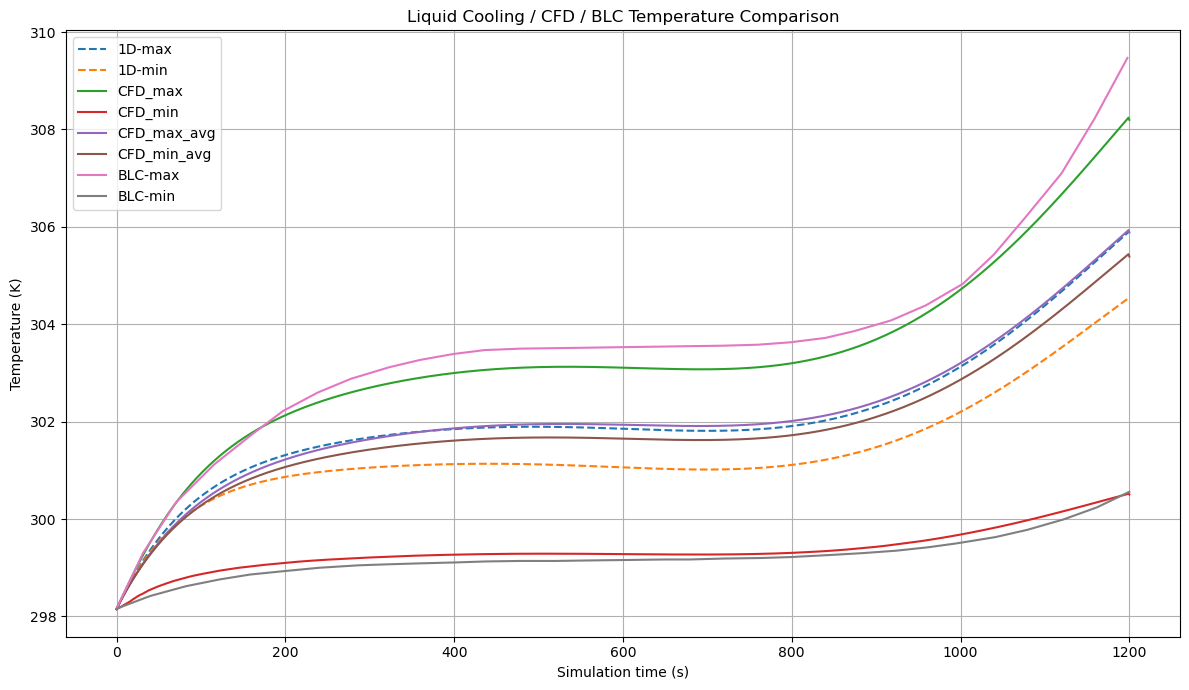

Saved comparison plot to: d:\Workspace\eBATS\out\liquid_results_blc_15cells\plot_liquid_cfd_avg_comparison.png
Loaded CFD series: CFD_max rows=1201, CFD_min rows=1201, CFD_max_avg rows=1201, CFD_min_avg rows=1201


In [ ]:
# 要读取并绘制的 CFD 数据文件。
# 新增的两组数据为 min_avg.out 和 max_avg.out，图例分别为 CFD_min_avg 和 CFD_max_avg。
CFD_SERIES_FILES = {
    "CFD_max": "max.out",
    "CFD_min": "min.out",
    "CFD_max_avg": "max_avg.out",
    "CFD_min_avg": "min_avg.out",
}

# 读取本地 CFD 数据。
cfd_series = []
for label, filename in CFD_SERIES_FILES.items():
    data = try_read_out_temperature(filename, label)
    if data is not None:
        cfd_series.append((label, data))

# 额外给定数据：BLC-max
BLC_max = np.array([
    [0, 298.16],
    [31.30, 299.30],
    [70.31, 300.34],
    [115.61, 301.12],
    [160.61, 301.74],
    [197.32, 302.22],
    [238.62, 302.60],
    [277.63, 302.88],
    [323.52, 303.12],
    [360.23, 303.27],
    [399.24, 303.39],
    [435.95, 303.47],
    [479.54, 303.50],
    [520.84, 303.51],
    [562.14, 303.52],
    [598.85, 303.53],
    [640.15, 303.54],
    [676.86, 303.55],
    [718.16, 303.56],
    [759.46, 303.58],
    [798.47, 303.63],
    [839.77, 303.72],
    [874.19, 303.86],
    [917.78, 304.08],
    [959.08, 304.39],
    [1002.68, 304.83],
    [1039.39, 305.43],
    [1076.10, 306.18],
    [1119.69, 307.10],
    [1158.70, 308.22],
    [1197.71, 309.47],
], dtype=float)
# 额外给定数据：BLC-min
BLC_min = np.array([
    [0, 298.16],
    [39.76, 298.42],
    [81.92, 298.62],
    [121.98, 298.76],
    [157.81, 298.86],
    [197.87, 298.93],
    [240.04, 299.00],
    [286.44, 299.05],
    [320.18, 299.07],
    [358.14, 299.09],
    [402.42, 299.11],
    [438.28, 299.13],
    [478.34, 299.14],
    [520.52, 299.14],
    [558.49, 299.15],
    [604.89, 299.16],
    [649.17, 299.17],
    [678.70, 299.17],
    [720.87, 299.19],
    [763.05, 299.20],
    [798.91, 299.22],
    [843.19, 299.26],
    [883.26, 299.30],
    [923.32, 299.35],
    [961.27, 299.42],
    [995.01, 299.50],
    [1041.39, 299.63],
    [1079.34, 299.78],
    [1121.50, 299.99],
    [1161.54, 300.24],
    [1200, 300.56],
], dtype=float)


# 液冷模型结果：Tmax_1D / Tmin_1D 在前面 cell 中由 1D BLC 结果计算得到，统一转成 K 后绘图。
liquid_max_K = to_kelvin_if_celsius(Tmax_1D)
liquid_min_K = to_kelvin_if_celsius(Tmin_1D)

plt.figure(figsize=(12, 7))
plt.plot(time_s, liquid_max_K, linestyle="--", label="1D-max")
plt.plot(time_s, liquid_min_K, linestyle="--", label="1D-min")

# 绘制所有已成功读取的 CFD 数据，包括新增的 CFD_min_avg / CFD_max_avg。
for label, data in cfd_series:
    plt.plot(data["time_s"], data["temperature_K"], label=label)

plt.plot(BLC_max[:, 0], BLC_max[:, 1], label="BLC-max")
plt.plot(BLC_min[:, 0], BLC_min[:, 1], label="BLC-min")

plt.xlabel("Simulation time (s)")
plt.ylabel("Temperature (K)")
plt.title("Liquid Cooling / CFD / BLC Temperature Comparison")
plt.grid(True)
plt.legend()
plt.tight_layout()

plot_path = os.path.join(output_dir, "plot_liquid_cfd_avg_comparison.png")
plt.savefig(plot_path, dpi=600)
plt.show()

print(f"Saved comparison plot to: {plot_path}")
if cfd_series:
    print("Loaded CFD series:", ", ".join([f"{label} rows={len(data)}" for label, data in cfd_series]))
else:
    print("WARNING: no CFD .out files were loaded. Please check CFD_DATA_DIR and CFD_SERIES_FILES.")
